# Lowell Hospital Project.

In [55]:
# If you are in Jupyter Notebook, keep this line. If using a normal Python script, you can remove it.
%matplotlib inline 

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 1. SETUP DIRECTORY AND COLORS
SAVE_DIR = r'C:\Users\USER\Downloads\Archive\Archive\HealthCare_Project\HEALTH_CARE_PROJECT'
FILE_PATH = os.path.join(SAVE_DIR, '2.RAW_DATA.xlsx')

os.makedirs(SAVE_DIR, exist_ok=True) # Ensures the folder exists

COLORS = {
    'navy': '#0D2137', 'teal': '#028090', 'mint': '#02C39A',
    'orange': '#F4845F', 'gray': '#64748B', 'white': 'white',
    'red': '#C0392B', 'light_bg': '#F0F7F9'
}

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.facecolor': '#F8FBFC',
    'figure.facecolor': 'white',
})

# 2. LOAD AND CLEAN THE DATA
print("Loading data...")
df_raw = pd.read_excel(FILE_PATH, sheet_name='Case Study Dataset', header=None)
df = df_raw.iloc[1:].copy()
df.columns = ['_drop', 'Month', 'Occupancy_Rate', 'Unassisted_Fall_Rate', 'Staff_Resp_Score', 'Unassisted_Fall_Pct', 'Staff_Resp_Score_Pct', 'Benchmark']
df = df.drop(columns=['_drop'])

df = df[df['Month'] != 'Month'].dropna(subset=['Month'])
df['Month'] = pd.to_datetime(df['Month'], errors='coerce')
df = df.dropna(subset=['Month'])

df['Year'] = df['Month'].dt.year
df['MonthName'] = df['Month'].dt.strftime('%b')

for col in ['Occupancy_Rate', 'Unassisted_Fall_Rate', 'Staff_Resp_Score', 'Unassisted_Fall_Pct', 'Staff_Resp_Score_Pct']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. CALCULATE YEARLY AVERAGES
yearly = df.groupby('Year').agg(
    Occ=('Occupancy_Rate', 'mean'),
    Fall=('Unassisted_Fall_Rate', 'mean'),
    Resp=('Staff_Resp_Score', 'mean'),
    FallPct=('Unassisted_Fall_Pct', 'mean'),
    RespPct=('Staff_Resp_Score_Pct', 'mean')
).round(4)
years = list(yearly.index)

print("Data loaded. Generating charts...")





Loading data...
Data loaded. Generating charts...


In [ ]:
# If you are in Jupyter Notebook, keep this line. If using a normal Python script, you can remove it.
%matplotlib inline 

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 1. SETUP DIRECTORY AND COLORS
SAVE_DIR = r'C:\Users\USER\Downloads\Archive\Archive\HealthCare_Project\HEALTH_CARE_PROJECT'
FILE_PATH = os.path.join(SAVE_DIR, '2.RAW_DATA.xlsx')

os.makedirs(SAVE_DIR, exist_ok=True) # Ensures the folder exists

COLORS = {
    'navy': '#0D2137', 'teal': '#028090', 'mint': '#02C39A',
    'orange': '#F4845F', 'gray': '#64748B', 'white': 'white',
    'red': '#C0392B', 'light_bg': '#F0F7F9'
}

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.facecolor': '#F8FBFC',
    'figure.facecolor': 'white',
})

# 2. LOAD AND CLEAN THE DATA
print("Loading data...")
df_raw = pd.read_excel(FILE_PATH, sheet_name='Case Study Dataset', header=None)
df = df_raw.iloc[1:].copy()
df.columns = ['_drop', 'Month', 'Occupancy_Rate', 'Unassisted_Fall_Rate', 'Staff_Resp_Score', 'Unassisted_Fall_Pct', 'Staff_Resp_Score_Pct', 'Benchmark']
df = df.drop(columns=['_drop'])

df = df[df['Month'] != 'Month'].dropna(subset=['Month'])
df['Month'] = pd.to_datetime(df['Month'], errors='coerce')
df = df.dropna(subset=['Month'])

df['Year'] = df['Month'].dt.year
df['MonthName'] = df['Month'].dt.strftime('%b')

for col in ['Occupancy_Rate', 'Unassisted_Fall_Rate', 'Staff_Resp_Score', 'Unassisted_Fall_Pct', 'Staff_Resp_Score_Pct']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. CALCULATE YEARLY AVERAGES
yearly = df.groupby('Year').agg(
    Occ=('Occupancy_Rate', 'mean'),
    Fall=('Unassisted_Fall_Rate', 'mean'),
    Resp=('Staff_Resp_Score', 'mean'),
    FallPct=('Unassisted_Fall_Pct', 'mean'),
    RespPct=('Staff_Resp_Score_Pct', 'mean')
).round(4)
years = list(yearly.index)

print("Data loaded. Generating charts...")





#  CHART 1: Bed Occupancy Bar

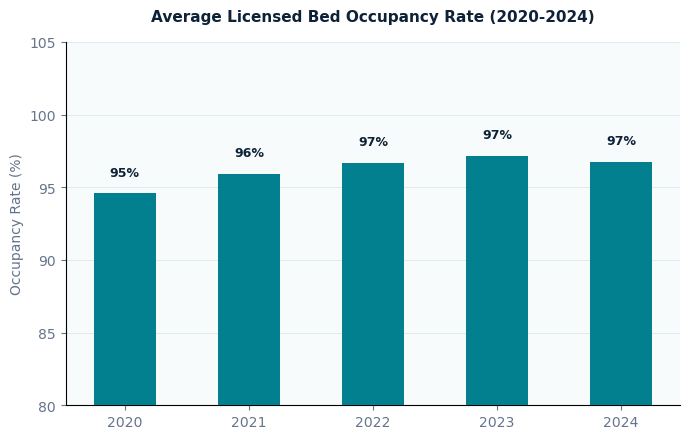

In [49]:

fig, ax = plt.subplots(figsize=(7, 4.5), facecolor='white')
bars = ax.bar(years, yearly['Occ']*100, color=COLORS['teal'], width=0.5, zorder=3)
ax.set_ylim(80, 105) 
ax.set_ylabel('Occupancy Rate (%)', color=COLORS['gray'], fontsize=10)
ax.set_title('Average Licensed Bed Occupancy Rate (2020-2024)', fontsize=11, fontweight='bold', color=COLORS['navy'], pad=15)
for bar, val in zip(bars, yearly['Occ']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.0, f'{val*100:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color=COLORS['navy'])
ax.tick_params(colors=COLORS['gray'])
ax.yaxis.grid(True, color='#E0EAEE', linewidth=0.7, zorder=0)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'chart_occupancy.png'), dpi=150, bbox_inches='tight')
plt.show()


# CHART 2: Staff Responsiveness vs Benchmark

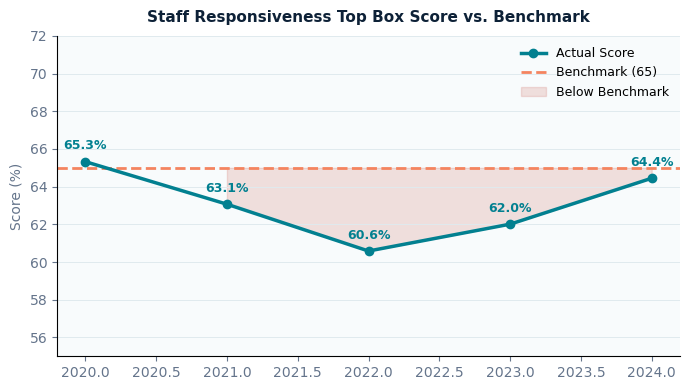

In [50]:

fig, ax = plt.subplots(figsize=(7, 4), facecolor='white')
ax.plot(years, yearly['Resp'], color=COLORS['teal'], marker='o', linewidth=2.5, markersize=6, label='Actual Score', zorder=3)
ax.axhline(y=65, color=COLORS['orange'], linewidth=2, linestyle='--', label='Benchmark (65)', zorder=2)
ax.fill_between(years, yearly['Resp'], 65, where=[v<65 for v in yearly['Resp']], alpha=0.15, color=COLORS['red'], label='Below Benchmark')
ax.fill_between(years, yearly['Resp'], 65, where=[v>=65 for v in yearly['Resp']], alpha=0.15, color=COLORS['mint'])
ax.set_ylim(55, 72)
ax.set_ylabel('Score (%)', color=COLORS['gray'], fontsize=10)
ax.set_title('Staff Responsiveness Top Box Score vs. Benchmark', fontsize=11, fontweight='bold', color=COLORS['navy'], pad=10)
for y, v in zip(years, yearly['Resp']):
    ax.text(y, v+0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color=COLORS['teal'])
ax.legend(fontsize=9, frameon=False)
ax.tick_params(colors=COLORS['gray'])
ax.yaxis.grid(True, color='#E0EAEE', linewidth=0.7, zorder=0)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'chart_staff.png'), dpi=150, bbox_inches='tight')
plt.show()

# CHART 3: Unassisted Fall Rate 

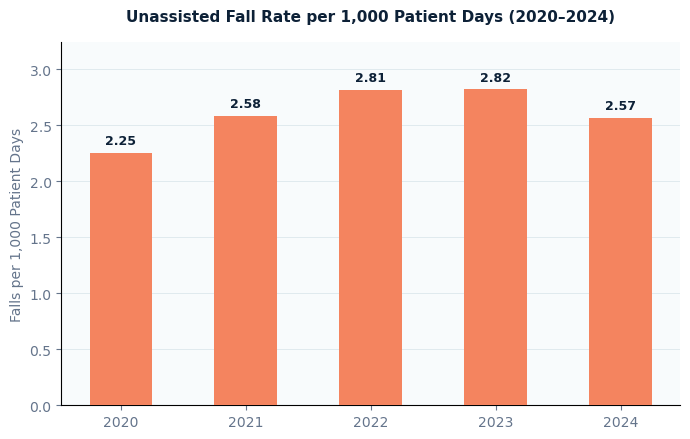

In [51]:

fig, ax = plt.subplots(figsize=(7, 4.5), facecolor='white')
bars = ax.bar(years, yearly['Fall'], color=COLORS['orange'], width=0.5, zorder=3)
ax.set_ylim(0, yearly['Fall'].max() * 1.15)
ax.set_ylabel('Falls per 1,000 Patient Days', color=COLORS['gray'], fontsize=10)
ax.set_title('Unassisted Fall Rate per 1,000 Patient Days (2020–2024)', fontsize=11, fontweight='bold', color=COLORS['navy'], pad=15)
for bar, val in zip(bars, yearly['Fall']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color=COLORS['navy'])
ax.tick_params(colors=COLORS['gray'])
ax.yaxis.grid(True, color='#E0EAEE', linewidth=0.7, zorder=0)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'chart_falls.png'), dpi=150, bbox_inches='tight')
plt.show()


#  CHART 4: All 3 KPIs grouped bar 

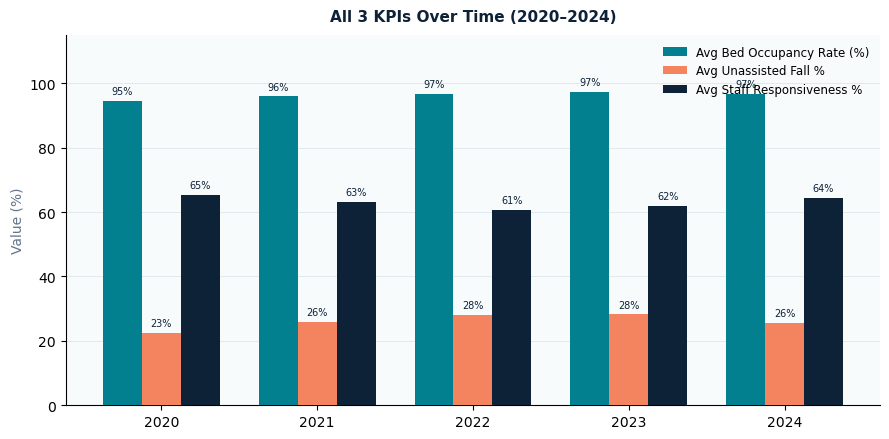

In [52]:

fig, ax = plt.subplots(figsize=(9, 4.5), facecolor='white')
x = np.arange(len(years))
w = 0.25
b1 = ax.bar(x - w, yearly['Occ']*100, w, label='Avg Bed Occupancy Rate (%)', color=COLORS['teal'], zorder=3)
b2 = ax.bar(x, yearly['FallPct']*100, w, label='Avg Unassisted Fall %', color=COLORS['orange'], zorder=3)
b3 = ax.bar(x + w, yearly['RespPct']*100, w, label='Avg Staff Responsiveness %', color=COLORS['navy'], zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_ylabel('Value (%)', color=COLORS['gray'], fontsize=10)
ax.set_title('All 3 KPIs Over Time (2020–2024)', fontsize=11, fontweight='bold', color=COLORS['navy'], pad=10)
ax.set_ylim(0, 115)
ax.legend(fontsize=8.5, frameon=False, loc='upper right')
ax.yaxis.grid(True, color='#E0EAEE', linewidth=0.7, zorder=0)
def label_bars(bars_list):
    for bar in bars_list:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 1.5, f'{h:.0f}%', ha='center', va='bottom', fontsize=7, color=COLORS['navy'])
label_bars(b1); label_bars(b2); label_bars(b3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'chart_all_kpis.png'), dpi=150, bbox_inches='tight')
plt.show()


# CHART 5: Scatter - Fall % vs Staff Resp

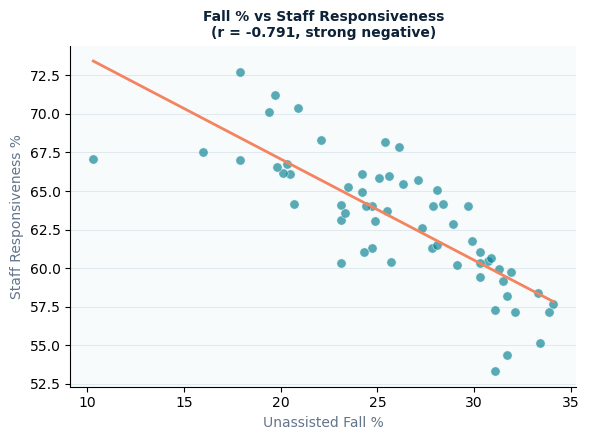

In [53]:

fig, ax = plt.subplots(figsize=(6, 4.5), facecolor='white')
x_vals = df['Unassisted_Fall_Pct'] * 100
y_vals = df['Staff_Resp_Score_Pct'] * 100
ax.scatter(x_vals, y_vals, color=COLORS['teal'], alpha=0.65, s=45, edgecolors='white', linewidth=0.5, zorder=3)
mask = ~np.isnan(x_vals) & ~np.isnan(y_vals)
m, b, r, p, _ = stats.linregress(x_vals[mask], y_vals[mask])
x_line = np.linspace(x_vals[mask].min(), x_vals[mask].max(), 100)
ax.plot(x_line, m*x_line+b, color=COLORS['orange'], linewidth=2, zorder=4)
ax.set_xlabel('Unassisted Fall %', color=COLORS['gray'], fontsize=10)
ax.set_ylabel('Staff Responsiveness %', color=COLORS['gray'], fontsize=10)
ax.set_title(f'Fall % vs Staff Responsiveness\n(r = {r:.3f}, strong negative)', fontsize=10, fontweight='bold', color=COLORS['navy'])
ax.yaxis.grid(True, color='#E0EAEE', linewidth=0.7, zorder=0)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'chart_scatter1.png'), dpi=150, bbox_inches='tight')
plt.show()

# CHART 6: Scatter - Occupancy vs Fall 

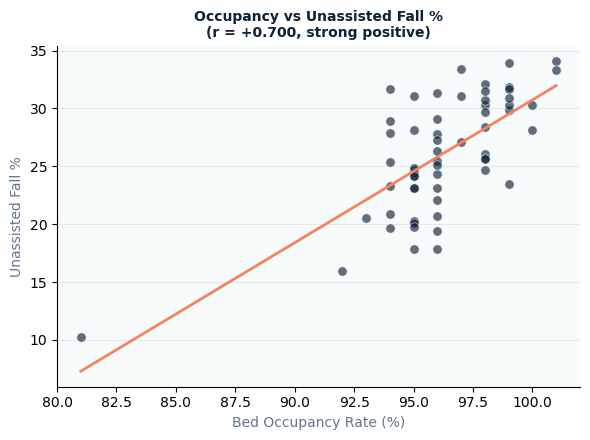

In [54]:

fig, ax = plt.subplots(figsize=(6, 4.5), facecolor='white')
x_vals2 = df['Occupancy_Rate'] * 100
y_vals2 = df['Unassisted_Fall_Pct'] * 100
ax.scatter(x_vals2, y_vals2, color=COLORS['navy'], alpha=0.65, s=45, edgecolors='white', linewidth=0.5, zorder=3)
mask2 = ~np.isnan(x_vals2) & ~np.isnan(y_vals2)
m2, b2, r2, p2, _ = stats.linregress(x_vals2[mask2], y_vals2[mask2])
x_line2 = np.linspace(x_vals2[mask2].min(), x_vals2[mask2].max(), 100)
ax.plot(x_line2, m2*x_line2+b2, color=COLORS['orange'], linewidth=2, zorder=4)
ax.set_xlabel('Bed Occupancy Rate (%)', color=COLORS['gray'], fontsize=10)
ax.set_ylabel('Unassisted Fall %', color=COLORS['gray'], fontsize=10)
ax.set_title(f'Occupancy vs Unassisted Fall %\n(r = {r2:+.3f}, strong positive)', fontsize=10, fontweight='bold', color=COLORS['navy'])
ax.yaxis.grid(True, color='#E0EAEE', linewidth=0.7, zorder=0)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'chart_scatter2.png'), dpi=150, bbox_inches='tight')
plt.show()

# CHART 7: Monthly trend (seasonality)

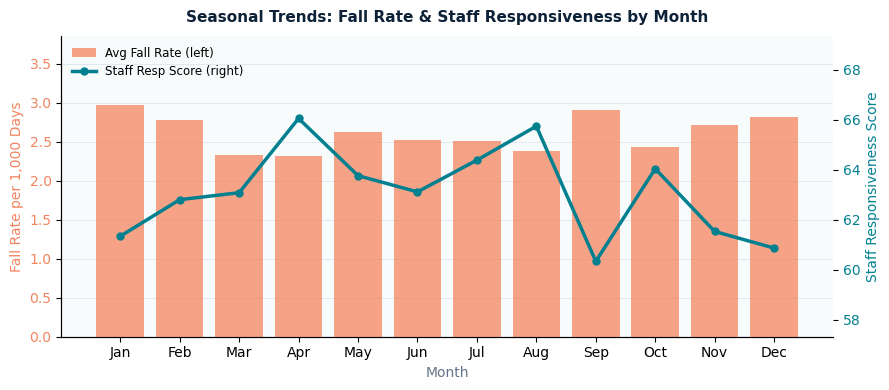

ALL CHARTS SUCCESSFULLY REGENERATED AND SAVED!


In [56]:

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('MonthName').agg(
    Avg_Fall=('Unassisted_Fall_Rate', 'mean'),
    Avg_Resp=('Staff_Resp_Score', 'mean')
).reindex(month_order)

fig, ax1 = plt.subplots(figsize=(9, 4), facecolor='white')
ax1.bar(month_order, monthly['Avg_Fall'], color=COLORS['orange'], alpha=0.75, zorder=3, label='Avg Fall Rate (left)')
ax1.set_ylabel('Fall Rate per 1,000 Days', color=COLORS['orange'], fontsize=10)
max_fall = monthly['Avg_Fall'].max()
ax1.set_ylim(0, max_fall * 1.3 if pd.notna(max_fall) else 1)
ax1.tick_params(axis='y', labelcolor=COLORS['orange'])
ax1.set_facecolor('#F8FBFC')

ax2 = ax1.twinx()
ax2.plot(month_order, monthly['Avg_Resp'], color=COLORS['teal'], marker='o', linewidth=2.5, markersize=5, label='Staff Resp Score (right)', zorder=4)
ax2.set_ylabel('Staff Responsiveness Score', color=COLORS['teal'], fontsize=10)
min_resp, max_resp = monthly['Avg_Resp'].min(), monthly['Avg_Resp'].max()
if pd.notna(min_resp) and pd.notna(max_resp):
    ax2.set_ylim(min_resp * 0.95, max_resp * 1.05)
ax2.tick_params(axis='y', labelcolor=COLORS['teal'])

ax1.set_title('Seasonal Trends: Fall Rate & Staff Responsiveness by Month', fontsize=11, fontweight='bold', color=COLORS['navy'], pad=10)
ax1.set_xlabel('Month', fontsize=10, color=COLORS['gray'])
ax1.yaxis.grid(True, color='#E0EAEE', linewidth=0.7, zorder=0)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8.5, frameon=False, loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'chart_seasonal.png'), dpi=150, bbox_inches='tight')
plt.show()

print("ALL CHARTS SUCCESSFULLY REGENERATED AND SAVED!")

In [57]:
# If python-pptx isn't installed, uncomment the next line and run it once:
# %pip install python-pptx

import os
from pptx import Presentation
from pptx.util import Inches
from pptx.dml.color import RGBColor

# 1. SETUP YOUR DIRECTORY
SAVE_DIR = r'C:\Users\USER\Downloads\Archive\Archive\HealthCare_Project\HEALTH_CARE_PROJECT'

# 2. CREATE PRESENTATION
prs = Presentation()

# Standard Slide Layouts
TITLE_SLIDE = 0
BULLET_SLIDE = 1
BLANK_SLIDE = 6
IMAGE_SLIDE = 5 # Title only layout for large images

# --- SLIDE 1: Title Slide ---
slide1 = prs.slides.add_slide(prs.slide_layouts[TITLE_SLIDE])
slide1.shapes.title.text = "LOWELL GENERAL HOSPITAL PROJECT"
slide1.placeholders[1].text = "Analyzing Insights for Patient Care & Safety\nPresented by: Lisha Bhowmik"

# --- SLIDE 2: Problem Statement ---
slide2 = prs.slides.add_slide(prs.slide_layouts[BULLET_SLIDE])
slide2.shapes.title.text = "Problem Statement"
tf2 = slide2.shapes.placeholders[1].text_frame
tf2.text = "Lowell General Hospital prioritizes patients above all else, but maintaining high standards requires constant monitoring."
p = tf2.add_paragraph()
p.text = "The Core Issue: Management recognizes that fluctuating hospital capacity can lead to patient dissatisfaction and safety risks."
p.level = 1
p = tf2.add_paragraph()
p.text = "Our Objective: To investigate how hospital crowdedness affects our staff's ability to respond to patients and prevent injuries."
p.level = 1
p = tf2.add_paragraph()
p.text = "We are analyzing three interconnected KPIs to uncover these operational bottlenecks:"
p = tf2.add_paragraph()
p.text = "1. Average Licensed Bed Occupancy Rate\n2. Staff Responsiveness Top Box Score\n3. Unassisted Patient Falls per 1000 Patient Days"
p.level = 1

# --- SLIDE 3: KPI Definitions ---
slide3 = prs.slides.add_slide(prs.slide_layouts[BULLET_SLIDE])
slide3.shapes.title.text = "Key Performance Indicators (KPIs)"
tf3 = slide3.shapes.placeholders[1].text_frame
tf3.text = "Average Occupancy Rate (%)"
p = tf3.add_paragraph()
p.text = "Captured internally. Measures the percentage of licensed beds filled per day."
p.level = 1
p = tf3.add_paragraph()
p.text = "Staff Responsiveness Top Box Score"
p = tf3.add_paragraph()
p.text = "Captured by HCAHPS Survey. Percentage of patients answering 'Always' to getting help quickly (Benchmark: 65%)."
p.level = 1
p = tf3.add_paragraph()
p.text = "Unassisted Patient Falls per 1000 Patient Days"
p = tf3.add_paragraph()
p.text = "Captured by NDNQI. Measures unplanned patient falls when no staff member is present to assist."
p.level = 1

# --- SLIDE 4: Overall KPI Trends (2020 - 2024) ---
slide4 = prs.slides.add_slide(prs.slide_layouts[IMAGE_SLIDE])
slide4.shapes.title.text = "Overall KPI Trends Over Time"
chart4_path = os.path.join(SAVE_DIR, 'chart_all_kpis.png')
if os.path.exists(chart4_path):
    slide4.shapes.add_picture(chart4_path, Inches(0.5), Inches(1.5), width=Inches(9))
txBox = slide4.shapes.add_textbox(Inches(0.5), Inches(6.0), Inches(9), Inches(1))
txBox.text_frame.text = "Insight: While bed occupancy remains consistently high, we observe visible fluctuations in staff responsiveness and patient fall rates year-over-year."

# --- SLIDE 5: Bed Occupancy Analysis ---
slide5 = prs.slides.add_slide(prs.slide_layouts[IMAGE_SLIDE])
slide5.shapes.title.text = "Metric 1: Bed Occupancy Remains Consistently High"
chart1_path = os.path.join(SAVE_DIR, 'chart_occupancy.png')
if os.path.exists(chart1_path):
    slide5.shapes.add_picture(chart1_path, Inches(1.5), Inches(1.5), width=Inches(7))
txBox2 = slide5.shapes.add_textbox(Inches(0.5), Inches(6.0), Inches(9), Inches(1))
txBox2.text_frame.text = "Insight: Occupancy increased slightly from 95% in 2020 to 97% (2022-2024). This indicates strong, continuous utilization of beds, leaving very little operational buffer."

# --- SLIDE 6: Staff Responsiveness vs Benchmark ---
slide6 = prs.slides.add_slide(prs.slide_layouts[IMAGE_SLIDE])
slide6.shapes.title.text = "Metric 2: Staff Responsiveness vs. Benchmark"
chart2_path = os.path.join(SAVE_DIR, 'chart_staff.png')
if os.path.exists(chart2_path):
    slide6.shapes.add_picture(chart2_path, Inches(1.5), Inches(1.5), width=Inches(7))
txBox3 = slide6.shapes.add_textbox(Inches(0.5), Inches(6.0), Inches(9), Inches(1))
txBox3.text_frame.text = "Insight: Scores declined from 65% in 2020 to 61% in 2022 (red zone), recovering to 64% by 2024. Staff are struggling to meet the 65% benchmark during peak periods."

# --- SLIDE 7: Unassisted Fall Rates ---
slide7 = prs.slides.add_slide(prs.slide_layouts[IMAGE_SLIDE])
slide7.shapes.title.text = "Metric 3: Unassisted Patient Falls"
chart3_path = os.path.join(SAVE_DIR, 'chart_falls.png')
if os.path.exists(chart3_path):
    slide7.shapes.add_picture(chart3_path, Inches(1.5), Inches(1.5), width=Inches(7))
txBox4 = slide7.shapes.add_textbox(Inches(0.5), Inches(6.0), Inches(9), Inches(1))
txBox4.text_frame.text = "Insight: Falls spiked significantly in 2022 and 2023, perfectly mirroring the years where staff responsiveness hit its lowest points."

# --- SLIDE 8: Correlation Analysis (The "Why") ---
slide8 = prs.slides.add_slide(prs.slide_layouts[IMAGE_SLIDE])
slide8.shapes.title.text = "Correlation: How Do These Metrics Interact?"
chart6_path = os.path.join(SAVE_DIR, 'chart_scatter2.png') # Occ vs Fall
chart5_path = os.path.join(SAVE_DIR, 'chart_scatter1.png') # Resp vs Fall
if os.path.exists(chart6_path):
    slide8.shapes.add_picture(chart6_path, Inches(0.2), Inches(1.8), width=Inches(4.7))
if os.path.exists(chart5_path):
    slide8.shapes.add_picture(chart5_path, Inches(5.1), Inches(1.8), width=Inches(4.7))
txBox5 = slide8.shapes.add_textbox(Inches(0.2), Inches(6.2), Inches(9.5), Inches(1))
tf5 = txBox5.text_frame
tf5.text = "Left Chart: Strong Positive Correlation (+0.700). Higher bed occupancy directly leads to more falls."
p = tf5.add_paragraph()
p.text = "Right Chart: Strong Negative Correlation (-0.791). When staff responsiveness drops, unassisted falls spike drastically."

# --- SLIDE 9: Seasonal Bottlenecks ---
slide9 = prs.slides.add_slide(prs.slide_layouts[IMAGE_SLIDE])
slide9.shapes.title.text = "Seasonal Trends & Operational Bottlenecks"
chart7_path = os.path.join(SAVE_DIR, 'chart_seasonal.png')
if os.path.exists(chart7_path):
    slide9.shapes.add_picture(chart7_path, Inches(0.5), Inches(1.5), width=Inches(9))
txBox6 = slide9.shapes.add_textbox(Inches(0.5), Inches(6.0), Inches(9), Inches(1))
txBox6.text_frame.text = "Insight: Examining the data by month reveals clear seasonal inverse relationships. When fall rates peak in specific months, staff responsiveness is at its lowest."

# --- SLIDE 10: Proposed Solutions ---
slide10 = prs.slides.add_slide(prs.slide_layouts[BULLET_SLIDE])
slide10.shapes.title.text = "Solutions & Recommendations"
tf10 = slide10.shapes.placeholders[1].text_frame
tf10.text = "Based on the data analysis, we recommend the following actions:"
p = tf10.add_paragraph()
p.text = "1. Dynamic Staffing Models"
p.level = 1
p = tf10.add_paragraph()
p.text = "Implement predictive staffing. When bed occupancy is forecasted to exceed 95%, trigger additional support staff specifically for patient calls."
p.level = 2
p = tf10.add_paragraph()
p.text = "2. Proactive 'Bathroom Rounding'"
p.level = 1
p = tf10.add_paragraph()
p.text = "During peak seasonal months, mandate scheduled checks (e.g., every 2 hours) to assist patients before they attempt to get up unassisted."
p.level = 2
p = tf10.add_paragraph()
p.text = "3. Targeted Staff Training"
p.level = 1
p = tf10.add_paragraph()
p.text = "Focus on increasing alertness and prioritizing call buttons during high-occupancy shifts to safeguard the hospital's reputation and patient safety."
p.level = 2

# --- SLIDE 11: Conclusion & Thank You ---
slide11 = prs.slides.add_slide(prs.slide_layouts[TITLE_SLIDE])
slide11.shapes.title.text = "Conclusion"
slide11.placeholders[1].text = "Maintaining an optimal bed occupancy rate, alongside improved staff responsiveness, is essential for ensuring patient safety.\n\nLong-term success depends on continuously refining our operational strategies.\n\nTHANK YOU!!\nPresentation made by: Lisha Bhowmik"

# 3. SAVE THE PPTX FILE
ppt_path = os.path.join(SAVE_DIR, 'Lowell_Hospital_Project_Lisha.pptx')
prs.save(ppt_path)

print(f"Presentation successfully created at: {ppt_path}")

Presentation successfully created at: C:\Users\USER\Downloads\Archive\Archive\HealthCare_Project\HEALTH_CARE_PROJECT\Lowell_Hospital_Project_Lisha.pptx
